In [1]:
#%% Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
import math
from PIL import Image
from matplotlib.ticker import MaxNLocator

from scipy.signal import welch
from scipy.optimize import curve_fit
import re
from scipy.signal import savgol_filter
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Circle
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
from numba import njit, jit
from scipy import constants

## Spin Texture Construction

In [105]:
def skyrmion_texture(x, y, Lx, Ly, R=5, helicity=0, vorticity=1):

    cx, cy = Lx / 2, Ly / 2
    dx, dy = x - cx, y - cy

    r = np.sqrt(dx**2 + dy**2) + 1e-9
    phi = np.arctan2(dy, dx)

    if r <= R:
        theta = np.pi * (1 - r / R)
    else:
        theta = 0.0

    nx = np.sin(theta) * np.cos(vorticity * phi + helicity)
    ny = np.sin(theta) * np.sin(vorticity * phi + helicity)
    nz = np.cos(theta)

    return nx, ny, nz

def plot_spin_texture(grid_size=4, R=1.5, helicity=0, vorticity=1):

    points = np.arange(grid_size) + 0.5
    X, Y = np.meshgrid(points, points)

    Sx = np.zeros_like(X)
    Sy = np.zeros_like(Y)
    Sz = np.zeros_like(X)

    # 2. Calculate vectors at cell centers
    for i in range(grid_size):
        for j in range(grid_size):
            # Pass grid_size as Lx, Ly to skyrmion_texture
            nx, ny, nz = skyrmion_texture(X[j, i], Y[j, i], grid_size, grid_size, R, helicity, vorticity)
            Sx[j, i] = nx
            Sy[j, i] = ny
            Sz[j, i] = nz

    plt.figure(figsize=(6, 6))


    plt.imshow(Sz, origin='lower', cmap='RdYlBu', extent=[0, grid_size, 0, grid_size], interpolation='nearest')
    plt.colorbar(label="Spin $S_z$", fraction=0.046, pad=0.04)

    # 4. Plot the arrows at the centers (X, Y)
    plt.quiver(X, Y, Sx, Sy, color='black', pivot='middle', scale=15)

    plt.title(f"4x4 Skyrmions (V={vorticity}, H={helicity})")
    plt.xticks(np.arange(grid_size + 1))
    plt.yticks(np.arange(grid_size + 1))
    plt.grid(True, which='both', color='white', linestyle='-', linewidth=0.5, alpha=0.3)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.tight_layout()
    plt.show()

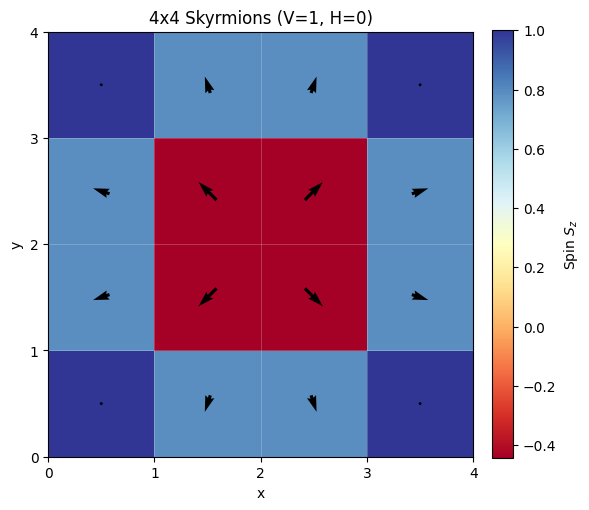

In [91]:
plot_spin_texture(grid_size=4, R=2, helicity=0, vorticity=1)

## Band Structure

In [99]:
def bloch_hamiltonian(kx, ky, Lx=4, Ly=4, t=1.0):
    """Returns Projected (adiabatic) Bloch Hamiltonian as a matrix.
    """

    N = Lx * Ly
    H = np.zeros((N, N), dtype=complex)

    def idx(x, y):
        return x * Ly + y

    theta = np.zeros((Lx, Ly))
    phi = np.zeros((Lx, Ly))

    for x in range(Lx):
        for y in range(Ly):
            S = skyrmion_texture(x, y, Lx, Ly, helicity=0, vorticity=1)

            # spherical angles
            theta[x, y] = np.arccos(S[2])
            phi[x, y] = np.arctan2(S[1], S[0])

    def t_eff(i_theta, i_phi, j_theta, j_phi):
        return t * (
            np.cos(i_theta/2)*np.cos(j_theta/2)
            + np.sin(i_theta/2)*np.sin(j_theta/2)
            * np.exp(-1j*(i_phi - j_phi))
        )
    
    for x in range(Lx):
        for y in range(Ly):

            i = idx(x, y)

            xp = (x + 1) % Lx
            j = idx(xp, y)

            hop = t_eff(theta[x,y], phi[x,y],
                        theta[xp,y], phi[xp,y])

            phase = np.exp(1j*kx*Lx) if xp == 0 else 1.0

            H[i, j] += -hop * phase
            H[j, i] += -np.conj(hop * phase)

            yp = (y + 1) % Ly
            j = idx(x, yp)

            hop = t_eff(theta[x,y], phi[x,y],
                        theta[x,yp], phi[x,yp])

            phase = np.exp(1j*ky*Ly) if yp == 0 else 1.0

            H[i, j] += -hop * phase
            H[j, i] += -np.conj(hop * phase)

    return H

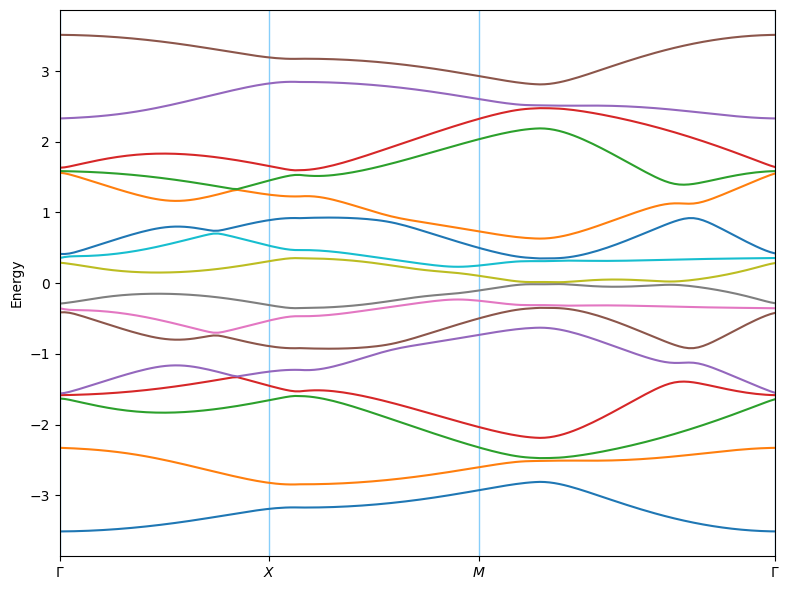

In [102]:
Gamma = np.array([0, 0])
X = np.array([np.pi/4, 0])
M = np.array([np.pi/4, np.pi/4])

points_per_seg = 50
path_segments = [
    (Gamma, X),
    (X, M),
    (M, Gamma)
]

k_points = []
k_dist = [0]

for start, end in path_segments:
    seg = np.linspace(start, end, points_per_seg, endpoint=False)
    k_points.append(seg)
    dist = np.linalg.norm(end - start)
    k_dist.append(k_dist[-1] + dist)

k_points = np.vstack(k_points)
total_dist = np.linspace(0, k_dist[-1], len(k_points))

all_energies = []
for kp in k_points:
    H = bloch_hamiltonian(kp[0], kp[1])
    eigs = np.linalg.eigvalsh(H)
    mid = len(eigs) // 2
    selected_bands = eigs[max(0, mid-5) : min(len(eigs), mid+5)]
    all_energies.append(eigs) # Change eigs to selected_bands to zoom into the bands near E = 0

all_energies = np.array(all_energies)

plt.figure(figsize=(8, 6))

for i in range(all_energies.shape[1]):
    plt.plot(total_dist, all_energies[:, i], lw=1.5)

for d in k_dist:
    plt.axvline(d, color='lightskyblue', linestyle='-', linewidth=1, zorder=0)

plt.xticks(k_dist, [r'$\Gamma$', r'$X$', r'$M$', r'$\Gamma$'])
plt.xlim(0, k_dist[-1])
plt.ylabel("Energy")
plt.tight_layout()
plt.show()

## Topological Hall Conductivity

In [106]:
def compute_chern_numbers(kx_vals, ky_vals, Lx=4, Ly=4, t=1.0):
    Nkx, Nky = len(kx_vals), len(ky_vals)
    Nb = Lx * Ly

    eigvecs = np.zeros((Nkx, Nky, Nb, Nb), dtype=complex)

    for i, kx in enumerate(kx_vals):
        for j, ky in enumerate(ky_vals):
            H = bloch_hamiltonian(kx, ky, Lx, Ly, t)
            E, U = np.linalg.eigh(H)

            idx = np.argsort(E)
            U = U[:, idx]

            eigvecs[i, j] = U

    F = np.zeros((Nb, Nkx, Nky))

    for n in range(Nb):
        for i in range(Nkx):
            for j in range(Nky):

                ip = (i + 1) % Nkx
                jp = (j + 1) % Nky

                u   = eigvecs[i, j, :, n]
                ux  = eigvecs[ip, j, :, n]
                uy  = eigvecs[i, jp, :, n]
                uxy = eigvecs[ip, jp, :, n]

                def link(a, b):
                    val = np.vdot(a, b)
                    return val / (np.abs(val) + 1e-14)

                U1 = link(u, ux)
                U2 = link(ux, uxy)
                U3 = link(uxy, uy)
                U4 = link(uy, u)

                F[n, i, j] = np.angle(U1 * U2 * U3 * U4)

    Chern = np.sum(F, axis=(1,2)) / (2*np.pi)

    return np.round(Chern.real, 6)


def compute_band_energies(kx_vals, ky_vals, Lx=4, Ly=4, t=1.0):
    Nb = Lx * Ly
    Nk = len(kx_vals) * len(ky_vals)

    energies = np.zeros((Nk, Nb))

    idx_k = 0
    for kx in kx_vals:
        for ky in ky_vals:
            H = bloch_hamiltonian(kx, ky, Lx, Ly, t)
            E, _ = np.linalg.eigh(H)

            energies[idx_k] = np.sort(E)
            idx_k += 1

    return np.mean(energies, axis=0)

def compute_thc_vs_fermi(E_bands, Chern, Ef_vals):
    sigma_xy = np.zeros_like(Ef_vals)

    for i, Ef in enumerate(Ef_vals):
        occupied = E_bands < Ef
        sigma_xy[i] = np.sum(Chern[occupied])

    return sigma_xy

Chern numbers: [ 0.  1. -1. -1. -0.  0. -1.  2.  2. -1.  0. -0. -1. -1.  1. -0.]
Sum: 0.0


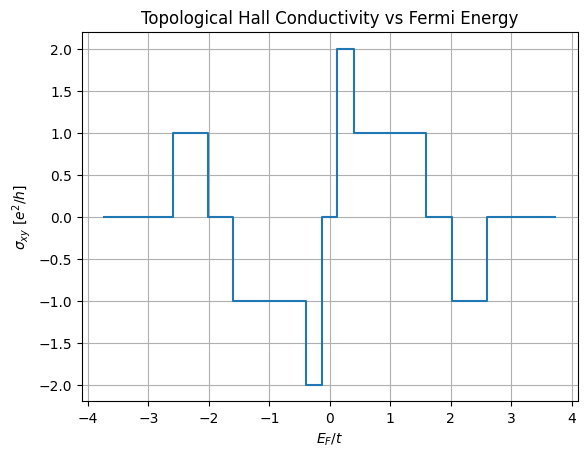

In [107]:
Nk = 41
kx_vals = np.linspace(-np.pi/4, np.pi/4, Nk, endpoint=False)
ky_vals = np.linspace(-np.pi/4, np.pi/4, Nk, endpoint=False)

chern = compute_chern_numbers(kx_vals, ky_vals)
print("Chern numbers:", chern)
print("Sum:", np.sum(chern))

E_bands = compute_band_energies(kx_vals, ky_vals)

Ef_vals = np.linspace(min(E_bands)-0.5, max(E_bands)+0.5, 300)
sigma_xy = compute_thc_vs_fermi(E_bands, chern, Ef_vals)

plt.figure()
plt.plot(Ef_vals, sigma_xy, drawstyle='steps-mid')
plt.xlabel(r'$E_F/t$')
plt.ylabel(r'$\sigma_{xy}$ [$e^2/h$]')
plt.title('Topological Hall Conductivity vs Fermi Energy')
plt.grid()
plt.show()